# Necrotic Area Subtraction from ROI

Remove poorly-perfused/necrotic regions from a segmentation mask using the PE parametric map.

- **PE (Peak Enhancement)**: Remove pixels with PE *below* threshold

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== FILE PATHS =====
PE_PATH = "/Users/samantha/Desktop/ultrasound lab stuff/china data/necrosis_testing/p34/v2/thresh_npy/PE_full_TIC_numerical.npy"
ROI_PATH = "/Users/samantha/Desktop/ultrasound lab stuff/china data/necrosis_testing/p34/v2/thresh_npy/segmentation.npy"
SCAN_PATH = '/Volumes/Extreme Pro/UCSD_SSD/ChinaData/3D-034/2nd/CEUS-26285-2.nii.gz'
OUTPUT_DIR = "/Users/samantha/Desktop/ultrasound lab stuff/china data/necrosis_testing/p34/v2/thresh_npy"

# ===== THRESHOLD =====
# Set value OR percentile (not both)

PE_THRESHOLD = None      # Absolute value, or None to use percentile
PE_PERCENTILE = 15       # Remove bottom 15% of PE values

In [20]:
# Load data
pe = np.load(PE_PATH)
roi = np.load(ROI_PATH)

orig_count = int(np.sum(roi > 0))
print(f"Shapes - PE: {pe.shape}, ROI: {roi.shape}")
print(f"Original ROI: {orig_count:,} pixels")

Shapes - PE: (240, 205, 128), ROI: (240, 205, 128)
Original ROI: 137,474 pixels


## PE Thresholding
Remove pixels with low Peak Enhancement (poor perfusion).

In [21]:
# Calculate threshold
if PE_THRESHOLD is not None:
    pe_thresh = PE_THRESHOLD
else:
    valid_pe = pe[(roi > 0) & np.isfinite(pe) & (pe > 0)]
    pe_thresh = np.percentile(valid_pe, PE_PERCENTILE)

# Apply threshold - remove pixels BELOW threshold
pe_mask = ((roi > 0) & (pe >= pe_thresh) & np.isfinite(pe)).astype(np.float32)

remaining = int(np.sum(pe_mask > 0))
print(f"PE threshold: {pe_thresh:.4f}")
print(f"Removed: {orig_count - remaining:,} pixels ({100*(orig_count-remaining)/orig_count:.1f}%)")
print(f"Remaining: {remaining:,} pixels")

PE threshold: 0.5312
Removed: 24,256 pixels (17.6%)
Remaining: 113,218 pixels


## Visualization

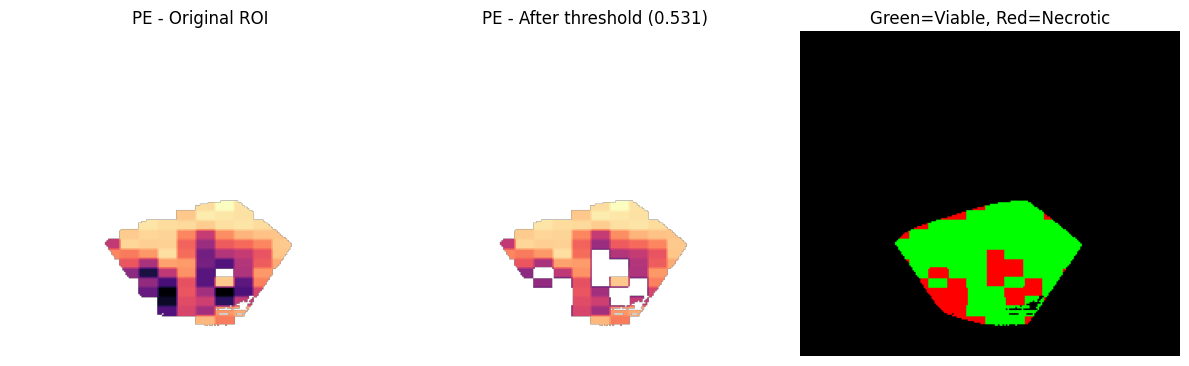

In [22]:
slice_idx = np.argmax([np.sum(roi[:,:,i] > 0) for i in range(roi.shape[2])])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

orig_slice = roi[:,:,slice_idx]
new_slice = pe_mask[:,:,slice_idx]
removed = (orig_slice > 0) & (new_slice == 0)

orig_data = np.where(orig_slice > 0, pe[:,:,slice_idx], np.nan)
vmin, vmax = np.nanmin(orig_data), np.nanmax(orig_data)

axes[0].imshow(np.rot90(orig_data), cmap='magma', vmin=vmin, vmax=vmax)
axes[0].set_title('PE - Original ROI')
axes[0].axis('off')

axes[1].imshow(np.rot90(np.where(new_slice > 0, pe[:,:,slice_idx], np.nan)), cmap='magma', vmin=vmin, vmax=vmax)
axes[1].set_title(f'PE - After threshold ({pe_thresh:.3f})')
axes[1].axis('off')

rgb = np.zeros((*orig_slice.shape, 3))
rgb[new_slice > 0] = [0, 1, 0]
rgb[removed] = [1, 0, 0]
axes[2].imshow(np.rot90(rgb))
axes[2].set_title('Green=Viable, Red=Necrotic')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [24]:
import napari
import nibabel as nib

# Load scan nifti - use middle timeframe for background
scan_nii = nib.load(SCAN_PATH)
scan = np.asarray(scan_nii.dataobj)
mid_frame = scan.shape[-1] // 2
scan_frame = scan[..., mid_frame].astype(np.float32)

# Build the necrotic-removed mask as a nifti (same grid as PE/ROI)
final_mask = (pe_mask > 0).astype(np.uint8)

# Save temp nifti for mask using scan's affine
mask_nii = nib.Nifti1Image(final_mask, scan_nii.affine)
roi_nii = nib.Nifti1Image(roi.astype(np.uint8), scan_nii.affine)

# Use affine transforms so napari aligns them properly
scan_affine = scan_nii.affine
mask_affine = mask_nii.affine

viewer = napari.Viewer()
viewer.add_image(scan_frame.transpose(2,1,0), name='Scan', colormap='gray',
                 scale=np.abs(np.diag(scan_affine)[:3])[::-1])
viewer.add_labels(roi.astype(np.uint8).transpose(2,1,0), name='Original ROI', visible=False, opacity=0.3,
                  scale=np.abs(np.diag(mask_affine)[:3])[::-1])
viewer.add_labels(final_mask.transpose(2,1,0), name='Necrotic Removed', opacity=0.3,
                  scale=np.abs(np.diag(mask_affine)[:3])[::-1])

<Labels layer 'Necrotic Removed' at 0x301447b10>

In [ ]:
import nibabel as nib

# Load affine from original scan
affine = nib.load(SCAN_PATH).affine

final_mask = (pe_mask > 0).astype(np.uint8)

# Save as nifti
nii_path = f"{OUTPUT_DIR}/voi_necrotic_removed.nii.gz"
nib.save(nib.Nifti1Image(final_mask, affine), nii_path)
print(f"Saved: {nii_path}")

# Save as npy
npy_path = f"{OUTPUT_DIR}/voi_necrotic_removed.npy"
np.save(npy_path, final_mask)
print(f"Saved: {npy_path}")

print(f"Voxels in mask: {int(np.sum(final_mask)):,}")